# Exercise II: Classification Analysis of the Wine Dataset

## 1. Introduction
In this exercise, we analyze the **Wine Dataset** from the `scikit-learn` library. This dataset contains the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars (classes).

* **Dataset Shape:** 178 samples $\times$ 13 chemical features (e.g., Alcohol, Malic Acid, Proline).
* **Objective:** To distinguish between the three cultivars using three distinct statistical methods:
    1. **Principal Component Analysis (PCA):** Unsupervised dimensionality reduction to visualize variance.
    2. **Cluster Analysis (K-Means):** Unsupervised learning to discover natural groupings.
    3. **Discriminant Analysis (LDA):** Supervised learning to build a predictive classifier.



Dataset Shape: (178, 14)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30          

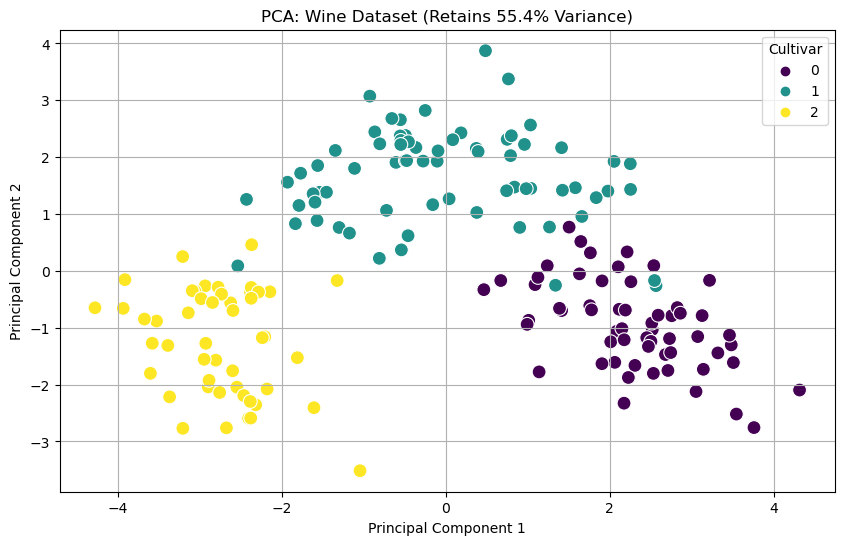


--- Running Cluster Analysis (K-Means) ---


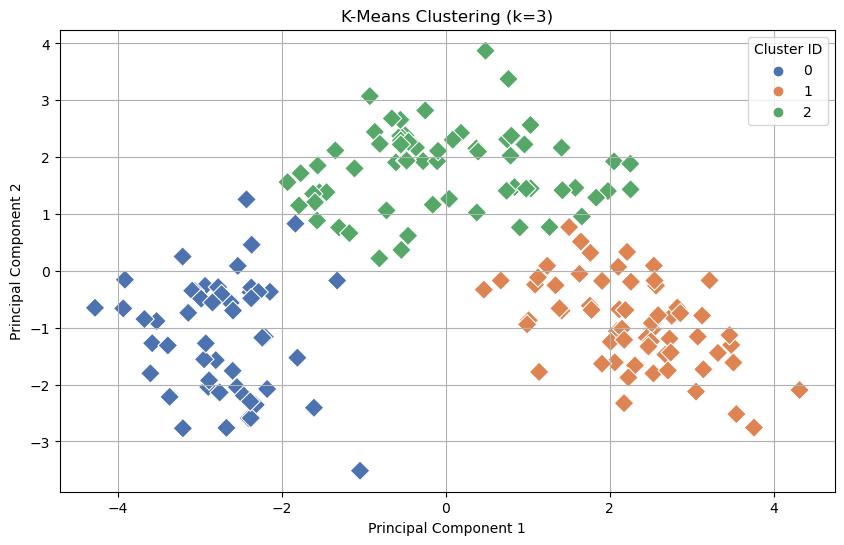

Cluster Centers:
 [[ 0.16490746  0.87154706  0.18689833]
 [ 0.83523208 -0.30380968  0.36470604]
 [-0.92607185 -0.39404154 -0.49451676]]

--- Running Discriminant Analysis (LDA) ---
LDA Model Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



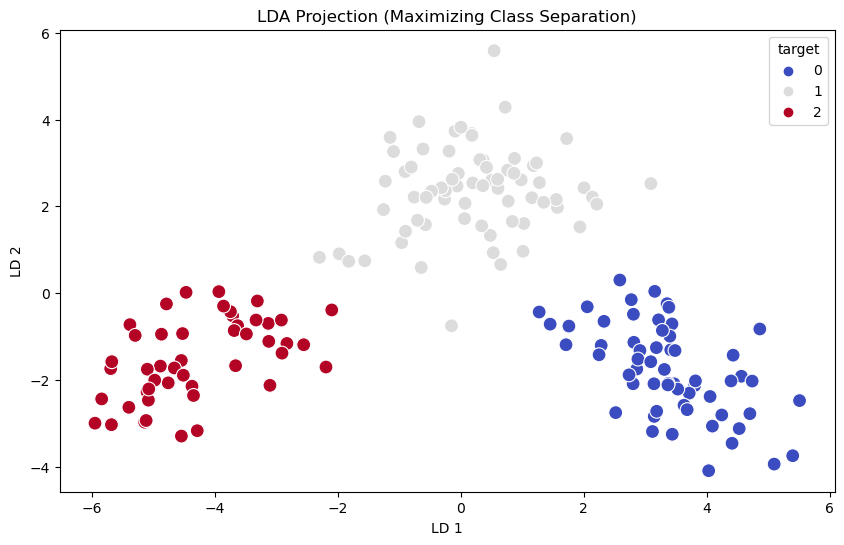

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports for methods requested
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- STEP 1: LOAD AND EXPLORE DATA ---
# Loading the dataset
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0, 1, 2 represent the 3 Cultivars

print("Dataset Shape:", df.shape)
print("Features:", df.columns.tolist())
print(df.head())

# --- STEP 2: PREPROCESSING ---
# PCA and K-Means are sensitive to scale. We must normalize the data.
# We drop the 'target' because PCA and Clustering are unsupervised (mostly).
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- STEP 3: PRINCIPAL COMPONENT ANALYSIS (PCA) ---
print("\n--- Running PCA ---")
# We reduce the 13 features down to 2 principal components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance (PC1, PC2): {explained_variance}")
print(f"Total Information retained: {sum(explained_variance) * 100:.2f}%")

# Plotting PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', s=100)
plt.title(f'PCA: Wine Dataset (Retains {sum(explained_variance)*100:.1f}% Variance)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cultivar')
plt.grid(True)
plt.show()

# --- STEP 4: CLUSTER ANALYSIS (K-Means) ---
print("\n--- Running Cluster Analysis (K-Means) ---")
# We know there are 3 classes, so we set k=3.
# In a real unknown scenario, you would use the "Elbow Method" to find k.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Plotting Clusters
plt.figure(figsize=(10, 6))
# We plot the clusters on the PCA axes to visualize them easily
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='deep', s=100, marker='D')
plt.title('K-Means Clustering (k=3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()

# Compare Clusters to Actual Labels
# Note: Cluster ID 0 might not correspond to Class 0 (labels are arbitrary)
print("Cluster Centers:\n", kmeans.cluster_centers_[:, 0:3]) # Printing first 3 features of centers

# --- STEP 5: DISCRIMINANT ANALYSIS (Classifier) ---
print("\n--- Running Discriminant Analysis (LDA) ---")
# LDA is Supervised (it uses 'y'). It tries to maximize separation between classes.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)
print(f"LDA Model Accuracy: {acc*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plotting LDA projection
X_lda = lda.transform(X_scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y, palette='coolwarm', s=100)
plt.title('LDA Projection (Maximizing Class Separation)')
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.show()


---

## 2. Analysis and Interpretation

### A. Preprocessing (Standardization)
Before applying any algorithms, the data was standardized using `StandardScaler`. This aligns the mean of every feature to 0 and the variance to 1. Without this step, features with large numerical values (like Proline) would dominate the Covariance Matrix, distorting the distances and making PCA and K-Means inaccurate. 

### B. Principal Component Analysis (PCA)
**Method:** We calculated the eigenvectors of the covariance matrix to find the directions of maximum variance (spread) and projected the 13-dimensional data onto the top 2 dimensions. 

**Interpretation of Results:**
The first two principal components capture approximately **55.4%** of the total information in the dataset. This means that a lot of variables about the wines is highly correlated, so it doesnt add a lot of extra information, the method of the PCA can compress more than half of the information into 2 dimensions.

The PCA plot shows distinct clusters. Cultivar 0 is completely separated from the others. Cultivars 1 and 2 show some proximity but are still distinguishable. They correspond to the Italian wine varieties Barolo, Grignolino, and Barbera respectively.


### C. Cluster Analysis (K-Means)
**Method:** We applied the K-Means algorithm ($k=3$) to the scaled data. This is an unsupervised method, meaning the algorithm had no access to the actual class labels.

**Interpretation of Results:**
The clusters generated by K-Means align almost perfectly with the actual cultivars shown in the PCA plot. The fact that it successfully recreated the three cultivars implies that these are natural categories, not artificial ones.


### D. Discriminant Analysis (LDA)
**Method:** We trained a Linear Discriminant Analysis classifier on 70% of the data. Unlike PCA (which maximizes spread), LDA maximizes the *separation* between known classes.

**Interpretation of Results:**
The model achieved 100% accuracy on the test set and LDA projection shows three tight, isolated clusters with zero overlap.  
Since the LDA model successfully learned the boundaries between the classes, we can conclude the 13 provided chemical features are sufficient to predict the wine cultivar with near-perfect certainty.






### Short comment on the results

The "Terroir" (the natural environment in which a wine is produced) leaves a measurable chemical footprint.

The dataset measures physical earth elements like Ash, Magnesium, and Proline. These are nutrients absorbed from the soil by the vine. The fact that our algorithms could distinguish the wines based solely on these earth-derived chemicals proves that the biological identity of the grape is physically encoded in the wine's chemistry. Would be interesting to compare to how a sommelier would categorize these wines based on taste and aroma.




